In [1]:
import arviz as az
import numpy as np
import pandas as pd
import pymc as pm

from pymc_extras.marginal import marginalize

## The original model

In [2]:
# TODO: Try to handle np.nan
# fmt: off
disaster_data = pd.Series(
    [4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
     3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
     2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,
     1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
     0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
     3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
     0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1]
)
# fmt: on

years = np.arange(1851, 1962)

In [3]:
with pm.Model() as disaster_model:
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())

    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)
    rate = pm.math.switch(switchpoint >= years, early_rate, late_rate)

    disasters = pm.Poisson("disasters", rate, observed=disaster_data)

/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/pymc/model/core.py:1323: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/pymc/model/core.py:1337: ImputationWarning: Data in disasters contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


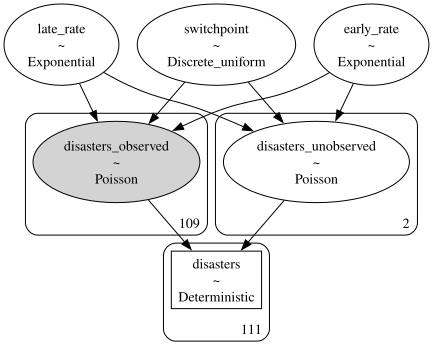

In [4]:
pm.model_to_graphviz(disaster_model)

In [5]:
with disaster_model:
    trace = pm.sample()

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Metropolis: [switchpoint]
>>Metropolis: [disasters_unobserved]
>NUTS: [early_rate, late_rate]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


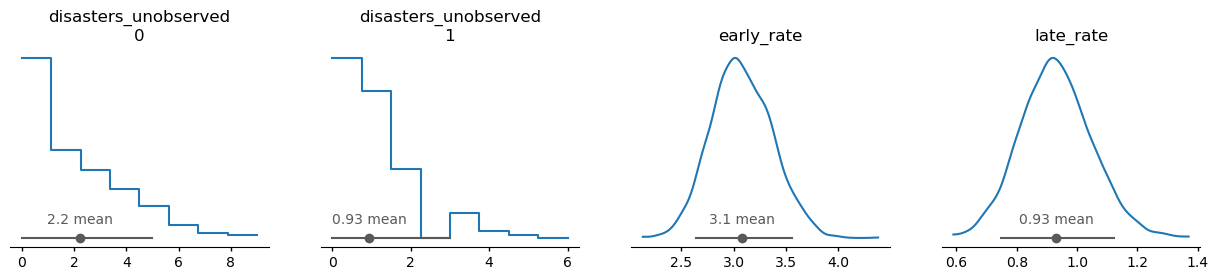

In [6]:
az.plot_dist(trace, var_names=["~switchpoint", "~disasters"]);

In [7]:
az.summary(trace, var_names=["~switchpoint", "~disasters"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
disasters_unobserved[0],2.2,1.8,0,5,323,382,1.01,0.097,0.072
disasters_unobserved[1],0.93,1.03,0,3,667,629,1.00,0.042,0.039
early_rate,3.08,0.289,2.6,3.6,2193,2187,1.00,0.0061,0.0043
late_rate,0.931,0.119,0.75,1.1,2821,2465,1.00,0.0022,0.0016


## Marginalized model

In [8]:
marginal_model = marginalize(disaster_model, ["switchpoint"])

/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run discrete_uniform_rv{"(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run discrete_uniform_rv{"(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run discrete_uniform_rv{"(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


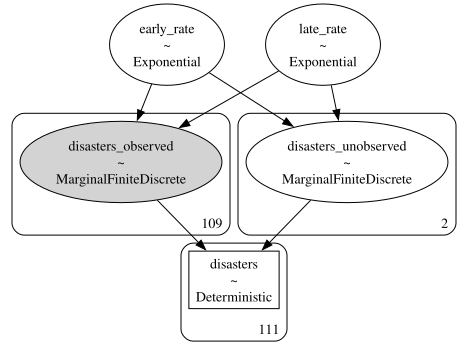

In [9]:
pm.model_to_graphviz(marginal_model)

In [10]:
with marginal_model:
    trace = pm.sample()

/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/model/marginal/distributions/enumerable.py:227: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: [4 5 4 0 1 ... 0 0 1 0 1].
  warn_non_separable_logp(values)
/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/model/marginal/distributions/enumerable.py:227: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: [4 5 4 0 1 ... 0 0 1 0 1].
  warn_non_separable_logp(values)
/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/model/marginal/distributions/enumerable.py:227: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: [4 5 4 0 1 ... 0 0 1 0 1].
  warn_non_separable_logp(values)
Multiprocess sampli

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


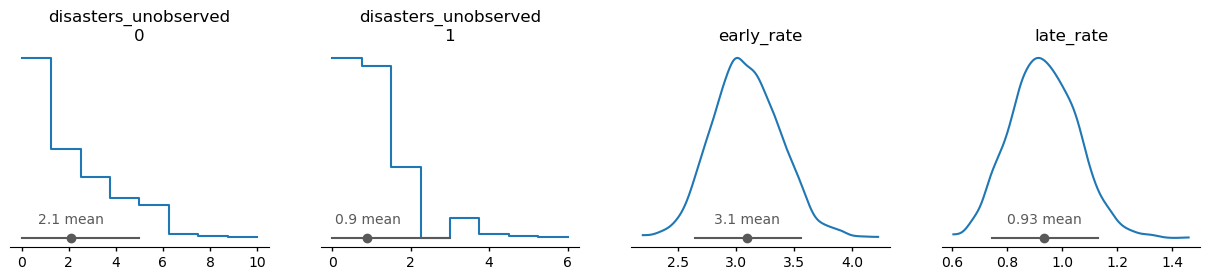

In [11]:
az.plot_dist(trace, var_names="~disasters");

In [12]:
az.summary(trace, var_names="~disasters")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
disasters_unobserved[0],2.1,1.8,0,5,239,314,1.01,0.12,0.098
disasters_unobserved[1],0.9,0.95,0,3,592,540,1.01,0.041,0.042
early_rate,3.093,0.292,2.7,3.6,4038,2683,1.00,0.0046,0.0033
late_rate,0.935,0.121,0.74,1.1,3477,2721,1.00,0.002,0.0014
